In [ ]:
import os
import warnings
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import tensorflow_datasets as tfds

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
import src.auxiliar as aux
import src.entropy_estimator as entropy_estimator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from ucimlrepo import fetch_ucirepo 
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

class_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']
model_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']

metrics = [
	'l1',
    'l2',
	'chebyshev',
	'hamming',
	'canberra',
	'braycurtis',
]

In [ ]:
models = [lambda : DecisionTreeClassifier(max_depth=10), 
    	  lambda : RandomForestClassifier(max_depth=5), 
		  lambda : KNeighborsClassifier(),
		  lambda : MLPClassifier(hidden_layer_sizes=[128,64,32], batch_size=32)]
names = ['Decision Tree', 'Random Forest', 'K Neighbors', 'Multilayer Perceptron']
short_name = ['dtc', 'rfc', 'knc', 'mlp']

In [142]:
def map_string_categories(array):
    import pandas as pd
    array = array.astype(object)
    result = array.copy()
    mappings = []
    for col_idx in range(array.shape[1]):
        column = array[:, col_idx]
        # Detect if the column contains strings or mixed types
        if np.issubdtype(column.dtype, np.object_):
            # Replace NaN values with a placeholder string for processing
            column = np.where(pd.isna(column), "<NaN>", column)
            if all(isinstance(val, str) for val in column):
                # Map unique strings to indices
                unique_values, indices = np.unique(column, return_inverse=True)
                # Replace "<NaN>" with -1 in indices and mappings
                nan_idx = np.where(unique_values == "<NaN>")[0][0] if "<NaN>" in unique_values else None
                if nan_idx is not None:
                    indices[indices == nan_idx] = -1
                    unique_values = np.delete(unique_values, nan_idx)
                # Update result and mappings
                result[:, col_idx] = indices
                mappings.append({i: val for i, val in enumerate(unique_values) if val != "<NaN>"})
            else:
                mappings.append(None)  # Non-string column, skip mapping
        else:
            mappings.append(None)  # Numeric or other non-string column
    return result, mappings

def subsample_dataset(x_data, y_data, proportion, seed=42):
    assert proportion > 0 and proportion <= 1, 'Proportion is invalid.'
    size = len(y_data)
    target_size = round(proportion * size)
    np.random.seed(seed)
    indices = np.random.choice(np.arange(size), size=target_size, replace=False)
    return x_data[indices], y_data[indices]

def estimate(x_data, y_data, export_name, proportion_space=np.linspace(0.1,1,10), num_models=10, num_shuffles=10):
	for p in proportion_space:
		with warnings.catch_warnings():
			warnings.filterwarnings("ignore", category=ConvergenceWarning)
			for m, n, sn in zip(models, names, short_name):
				train_accuracy, test_accuracy = [], []
				for i in range(num_models):
					for j in range(num_shuffles):
						sub_x_data, sub_y_data = subsample_dataset(x_data, y_data, p, seed=42+j)
						label, counts = np.unique(sub_y_data, return_counts=True)
						idx = np.argwhere(counts > 1)
						mask = np.isin(sub_y_data, label[idx])
						x_train, x_test, y_train, y_test = train_test_split(sub_x_data[mask], sub_y_data[mask], test_size=0.33, random_state=42+i, stratify=sub_y_data[mask])
						clf = m()
						clf = make_pipeline(StandardScaler(), clf)
						clf.fit(x_train, y_train)
						train_score = clf.score(x_train, y_train)
						test_score = clf.score(x_test, y_test)
						train_accuracy.append(train_score)
						test_accuracy.append(test_score)
				np.save(os.path.join('./data/real_world/', f'{export_name}_{sn}_{p:.3f}_train.npy'), train_accuracy)
				np.save(os.path.join('./data/real_world/', f'{export_name}_{sn}_{p:.3f}_test.npy'), test_accuracy)


In [169]:
def estimate_bootstraped_limit(x_data, y_data, export_name, max_neighbors=64, min_neighbors=16, proportion=0.8, num_shuffles=10):
	with np.errstate(divide='ignore', invalid='ignore'):
		cs = []
		for m in metrics:
			tmp_c = []
			for j in range(num_shuffles):
				sub_x_data, sub_y_data = subsample_dataset(x_data, y_data, proportion, seed=42+j)
				c = entropy_estimator.classificability_estimator(sub_x_data, sub_y_data, k_neighbors=min(max_neighbors, max(int(round(0.01 * len(sub_y_data))),min_neighbors)), metric=m, num_workers=32)
				tmp_c.append(c)
			cs.append(tmp_c)
	os.makedirs('./data/real_world/', exist_ok=True)
	np.save(os.path.join('./data/real_world/', f'{export_name}_bootstraped_limit.npy'), cs)

In [ ]:
models = [lambda : RandomForestClassifier(max_depth=5)]
names = ['Random Forest']
short_name = ['rfc']
proportion_space = np.linspace(0.1,1,20)

In [ ]:
# Abalon
# Nash, W., Sellers, T., Talbot, S., Cawthorn, A., & Ford, W. (1994). Abalone [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55C7W.
ds = np.genfromtxt('./other_datasets/abalon.csv', delimiter=',')
x_data, y_data = ds[:,:-1], ds[:,-1].astype(int)
young_mask = y_data <= 11
y_data[young_mask] = 0
y_data[~young_mask] = 1
estimate(x_data, y_data, 'abalon', proportion_space=proportion_space, num_models=10, num_shuffles=10)
estimate_bootstraped_limit(x_data, y_data, 'abalon', max_neighbors=64, min_neighbors=16, proportion=0.8, num_shuffles=10)

In [ ]:
# Adult
# Becker, B. & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.
ds = fetch_ucirepo(id=2) 
x_data = ds.data.features.to_numpy()
x_data = map_string_categories(x_data)[0]
y_data = ds.data.targets.to_numpy().reshape(-1)
y_data[y_data == '<=50K'] = 0
y_data[y_data == '<=50K.'] = 0
y_data[y_data == '>50K'] = 1
y_data[y_data == '>50K.'] = 1
y_data = y_data.astype(int)
estimate(x_data, y_data, 'adult', proportion_space=proportion_space, num_models=10, num_shuffles=10)
estimate_bootstraped_limit(x_data, y_data, 'adult', max_neighbors=64, min_neighbors=16, proportion=0.8, num_shuffles=10)

In [179]:
# Bank Marketing
# Moro, S., Rita, P., & Cortez, P. (2014). Bank Marketing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K306.
ds = fetch_ucirepo(id=222) 
x_data = ds.data.features.to_numpy()
x_data = map_string_categories(x_data)[0]
y_data = ds.data.targets.to_numpy().reshape(-1)
y_data[y_data == 'no'] = 0
y_data[y_data == 'yes'] = 1
y_data = y_data.astype(int)
estimate(x_data, y_data, 'bank_marketing', proportion_space=proportion_space, num_models=10, num_shuffles=10)
estimate_bootstraped_limit(x_data, y_data, 'bank_marketing', max_neighbors=64, min_neighbors=16, proportion=0.8, num_shuffles=10)

In [ ]:
# Wine Quality
# Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.
ds = fetch_ucirepo(id=186) 
x_data = ds.data.features.to_numpy()
y_data = ds.data.targets.to_numpy().reshape(-1)
y_data = y_data - np.min(y_data)
estimate(x_data, y_data, 'wine_quality', proportion_space=proportion_space, num_models=10, num_shuffles=10)
estimate_bootstraped_limit(x_data, y_data, 'wine_quality', max_neighbors=64, min_neighbors=16, proportion=0.8, num_shuffles=10)

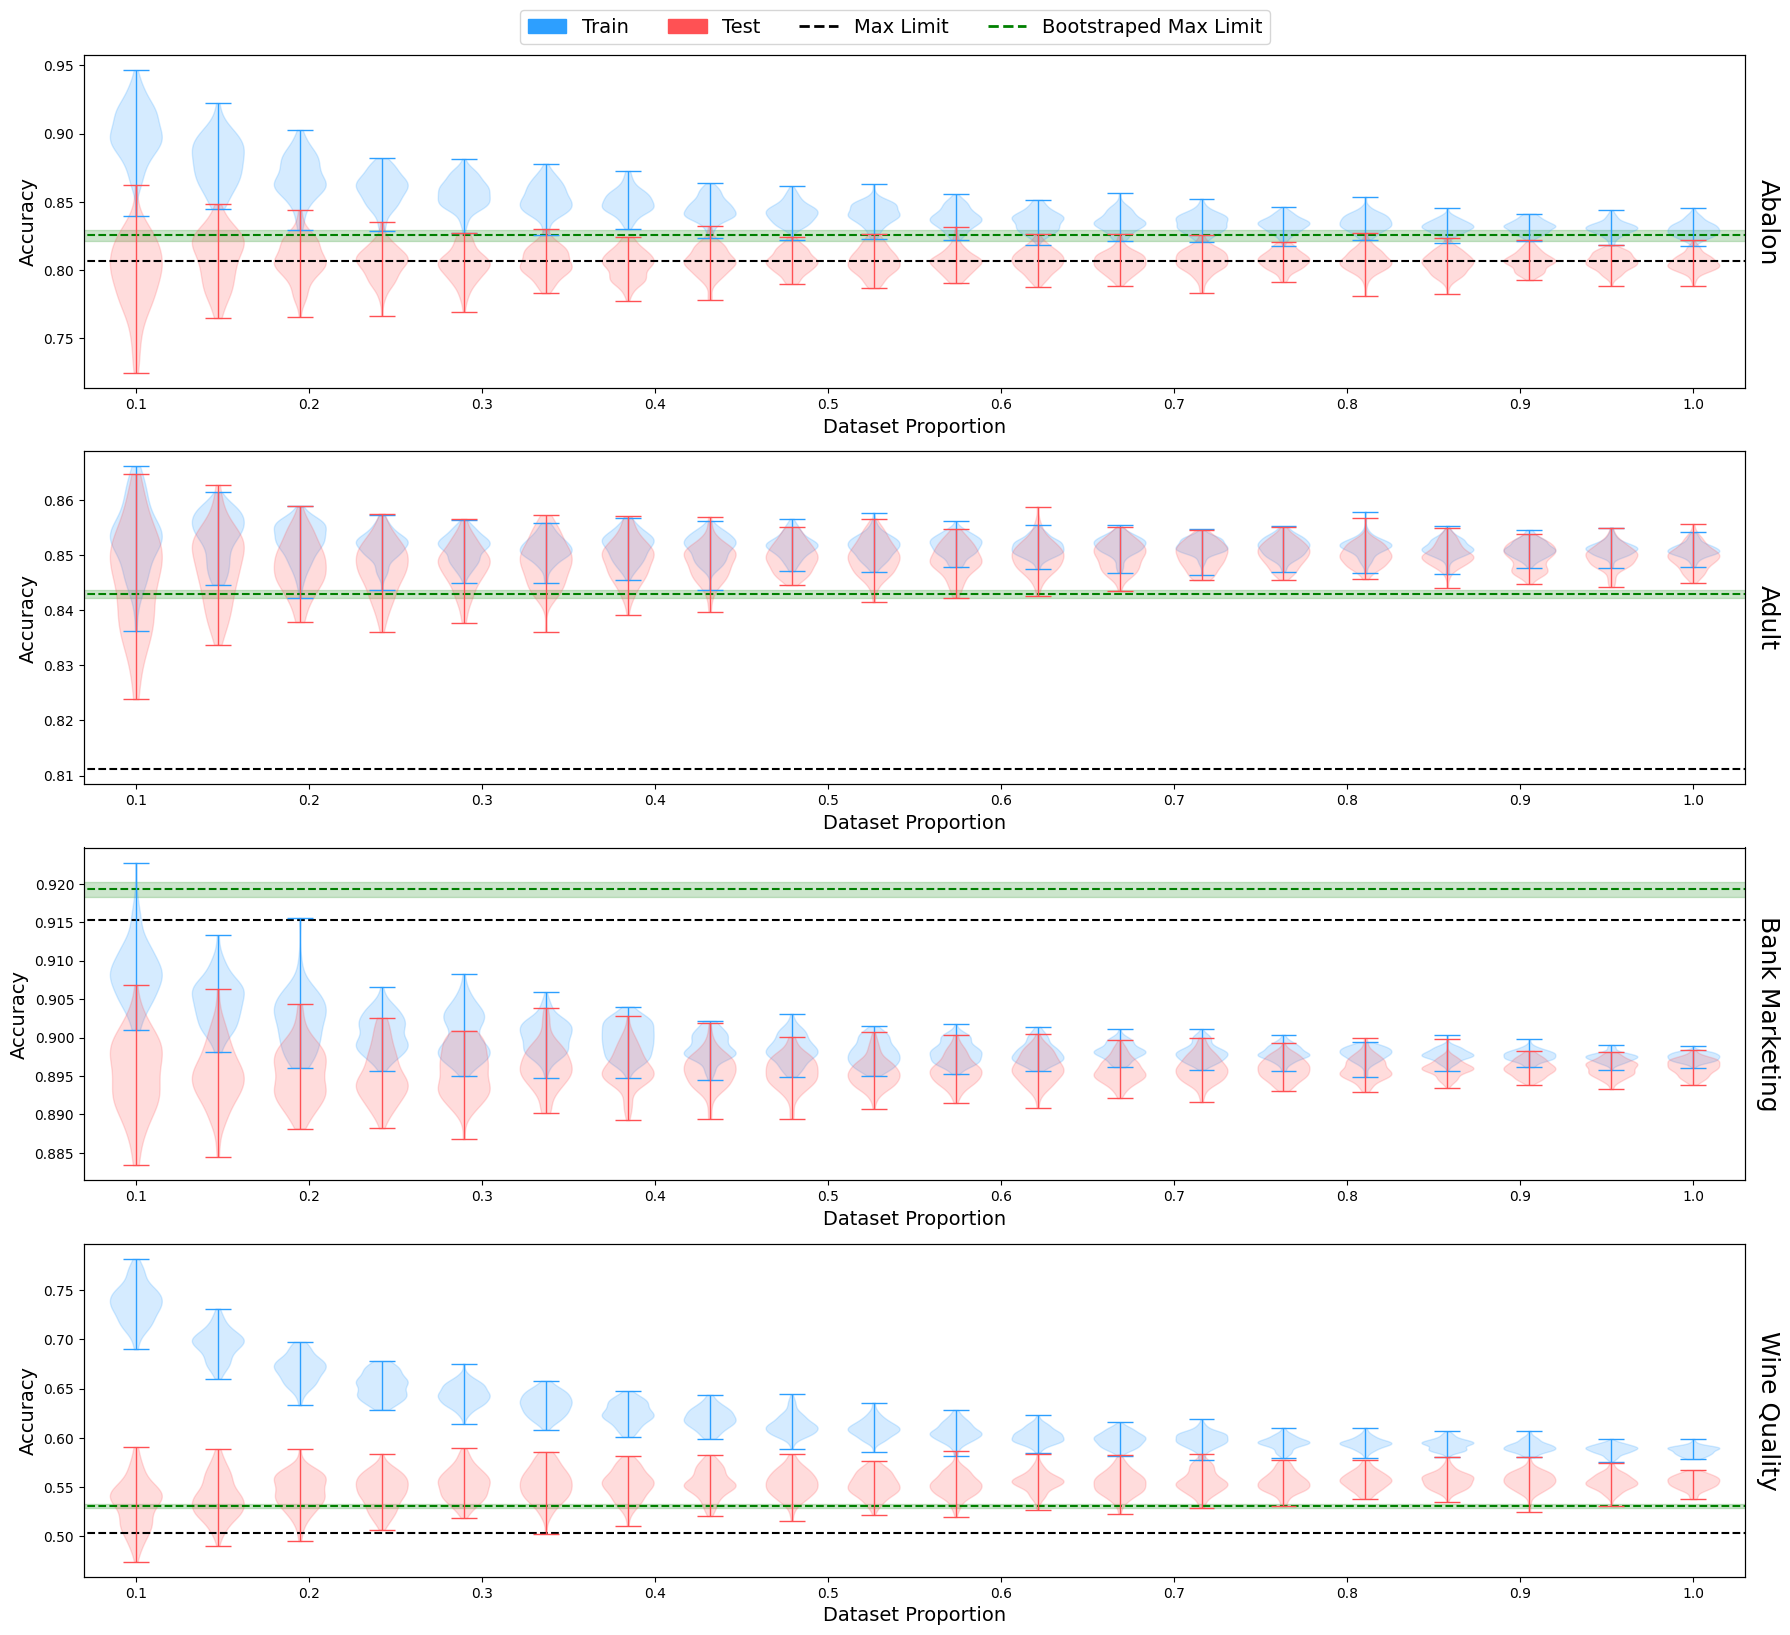

In [195]:
datasets = ['abalon', 'adult', 'bank_marketing', 'wine_quality']
datasets_names = ['Abalon', 'Adult', 'Bank Marketing', 'Wine Quality']
proportion_space = np.linspace(0.1,1,20)
lims = [(0.6,1), (0.6,1), (0.8,1), (0.4,0.8)]

fig, ax = plt.subplots(4, 1, figsize=(18,16))
for pos, (ds, ds_name) in enumerate(zip(datasets, datasets_names)):

	train_accuracy, test_accuracy = [], []
	for p in proportion_space:
		train_accuracy.append(np.load(os.path.join('./data/real_world/', f'{ds}_rfc_{p:.3f}_train.npy')))
		test_accuracy.append(np.load(os.path.join('./data/real_world/', f'{ds}_rfc_{p:.3f}_test.npy')))
	limit = np.load(os.path.join('./data/real_world/', f'{ds}_limit.npy'))


	blimit = np.load(os.path.join('./data/real_world/', f'{ds}_bootstraped_limit.npy'))
	blim_mean = np.mean(blimit, axis=1)
	blim_std = np.std(blimit, axis=1, ddof=1)
	limit_idx = np.argmax(blim_mean)
	ax[pos].plot([-1,2], 2*[blim_mean[limit_idx]], linestyle='--', color='g')
	ax[pos].fill_between([-1,2], 2*[blim_mean[limit_idx] - blim_std[limit_idx]], 2*[blim_mean[limit_idx] + blim_std[limit_idx]], color='g', alpha=0.2)
	if False:
		parts = ax[pos].violinplot(list(blimit), positions=np.arange(1,7)*0.1, widths=0.03)
		for pc in parts['bodies']:
			pc.set_facecolor('k')
			pc.set_edgecolor('k')
			pc.set_alpha(0.2)
		for partname in ('cbars','cmins','cmaxes'):
			vp = parts[partname]
			vp.set_edgecolor('k')
			vp.set_linewidth(1)

	ax[pos].plot([-1,2], 2*[np.max(limit)], 'k--')
	parts = ax[pos].violinplot(train_accuracy, positions=proportion_space, widths=0.03)
	for pc in parts['bodies']:
		pc.set_facecolor(class_colors[0])
		pc.set_edgecolor(class_colors[0])
		pc.set_alpha(0.2)
	for partname in ('cbars','cmins','cmaxes'):
		vp = parts[partname]
		vp.set_edgecolor(class_colors[0])
		vp.set_linewidth(1)
	parts = ax[pos].violinplot(test_accuracy, positions=proportion_space, widths=0.03)
	for pc in parts['bodies']:
		pc.set_facecolor(class_colors[1])
		pc.set_edgecolor(class_colors[1])
		pc.set_alpha(0.2)
	for partname in ('cbars','cmins','cmaxes'):
		vp = parts[partname]
		vp.set_edgecolor(class_colors[1])
		vp.set_linewidth(1)
	

	ax[pos].set_ylabel('Accuracy')
	ax[pos].set_xlim(0.07, 1.03)
	ax[pos].set_xticks(np.linspace(0.1,1,10))
	ax[pos].set_xlabel('Dataset Proportion')

	axtwin = ax[pos].twinx()
	axtwin.set_yticks([], [])
	axtwin.set_ylabel(ds_name, rotation=270, labelpad=25, fontsize=BIGGER_SIZE)

legend_elements = [Patch(facecolor=class_colors[0], edgecolor=class_colors[0], label='Train'),
				   Patch(facecolor=class_colors[1], edgecolor=class_colors[1], label='Test'),
				   Line2D([0], [0], color='k', lw=2, linestyle='--', label='Max Limit'),
				   Line2D([0], [0], color='g', lw=2, linestyle='--', label='Bootstraped Max Limit')]
fig.legend(handles=legend_elements, ncols=4, bbox_to_anchor=(0.5, 1.025), loc='upper center', fontsize=MEDIUM_SIZE)

plt.tight_layout()
plt.savefig('./images/real_world_datasets_subsample.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
datasets_name = ['Breast\nCancer', 'Iris', 'Digits', 'Wine', 'Pima\nDiabetes', 'Sonar', 'Banknote\nAuthentication', 'Abalon',
            'Ionosphere', 'Wheat\nSeeds', 'Heart\nDisease', 'Adult', 'Bank\nMarketing', 'Wine\nQuality', 'Student\nPerformance', 'Car\nEvaluation']
datasets_path = ['breast_cancer','iris','digits','wine','pima_diabetes','sonar','banknote_authentication','abalon',
                     'ionosphere','wheat_seeds','heart_disease','adult','bank_marketing','wine_quality','student_performance','car_evaluation']

names = ['Decision Tree', 'Random Forest', 'K Neighbors', 'Multilayer Perceptron']
short_name = ['dtc', 'rfc', 'knc', 'mlp']
x = np.arange(len(datasets_path)) * 9

plt.figure(figsize=(18,8))

limit = []
metric_name = []
for d in datasets_path:
	l = np.load(os.path.join('./data/real_world/', f'{d}_limit.npy'))
	idx = np.argmax(l)
	limit.append(l[idx])
	metric_name.append(metrics[idx])
limit = np.array(limit)

order = np.argsort(limit)#[::-1]
datasets_name = np.array(datasets_name)[order]
datasets_path = np.array(datasets_path)[order]

legend_elements = []
for i, (n, sn, c) in enumerate(zip(names, short_name, model_colors)):
	accuracies = []
	for d in datasets_path:
		test_accuracy = np.load(os.path.join('./data/real_world/', f'{d}_{sn}_test.npy'))
		accuracies.append(list(test_accuracy))
	parts = plt.violinplot(accuracies, positions=x+i, widths=1)
	for pc in parts['bodies']:
		pc.set_facecolor(c)
		pc.set_edgecolor(c)
		pc.set_alpha(0.3)
	for partname in ('cbars','cmins','cmaxes'):
		vp = parts[partname]
		vp.set_edgecolor(c)
		vp.set_linewidth(1)
	legend_elements.append(Patch(facecolor=c, edgecolor=c, label=n))


#legend_elements = []
limits = []
c = 'k'
for d in datasets_path:
	test_accuracy = np.load(os.path.join('./data/real_world/', f'{d}_limit.npy'))
	limits.append(list(test_accuracy))
parts = plt.violinplot(limits, positions=x+5, widths=1)
for pc in parts['bodies']:
	pc.set_facecolor(c)
	pc.set_edgecolor(c)
	pc.set_alpha(0.3)
for partname in ('cbars','cmins','cmaxes'):
	vp = parts[partname]
	vp.set_edgecolor(c)
	vp.set_linewidth(1)
legend_elements.append(Patch(facecolor=c, edgecolor=c, label='Limit'))

for i in range(len(limit)):
	plt.plot([x[i]-1, x[i]+5], [limit[order][i], limit[order][i]], 'k--', alpha=0.8)
	plt.text(x[i]+2, limit[order][i], metric_name[i], rotation=45, va='top')
legend_elements.append(Line2D([0], [0], color='k', lw=1, linestyle='--', label='Max Limit'))


plt.xticks(x+1.5, datasets_name, rotation=45, fontsize=MEDIUM_SIZE)
plt.legend(handles=legend_elements, ncols=6, bbox_to_anchor=(0.5, 1.15), loc='upper center', fontsize=MEDIUM_SIZE)
plt.ylim(0,1.025)
plt.xlim(x[0]-2, x[-1]+6)
plt.ylabel('Accuracy')

plt.tight_layout()
plt.savefig('./images/real_world_datasets.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
limits